<a href="https://colab.research.google.com/github/book150243/Homework_DADS6003/blob/main/HW_DADS6003_6810422005.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import log_loss

REMISS    1.000000
LI        0.541982
BLAST     0.361188
CELL      0.264529
INFIL     0.263997
SMEAR     0.199488
TEMP     -0.143963
Name: REMISS, dtype: float64


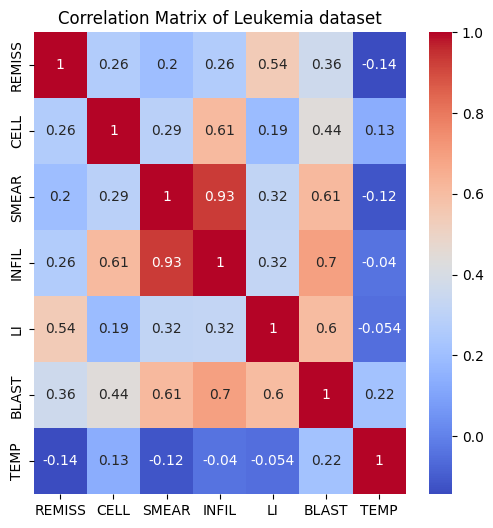

In [13]:
#upload text file
url = "https://raw.githubusercontent.com/book150243/Homework_DADS6003/refs/heads/main/leukemia_remission.txt"
leukemia_df = pd.read_csv(url,sep = "\t")

#find correlation
corr_matrix = leukemia_df.corr()
remiss_corr = corr_matrix["REMISS"].sort_values(ascending = False)
print(remiss_corr)

plt.figure(figsize=(6,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix of Leukemia dataset")
plt.show()

#define x and y
x = leukemia_df.drop(["REMISS", "TEMP", "SMEAR"], axis = 1) #or x = leukemia_df.iloc[:, 1:]
y = leukemia_df["REMISS"]

# Logistic Regression

In [14]:
#Split data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 24)

#Train: use logistics regression to fit x_train and y_train and get model
logreg = LogisticRegression()
logreg.fit(x_train,y_train)

#Test
y_pred = logreg.predict(x_test)
y_pred_proba = logreg.predict_proba(x_test)

#evaluate
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(f"theta0 : {logreg.intercept_[0]:.4f}")

for i in range(len(logreg.coef_[0])):
    print(f"theta{i+1} : {logreg.coef_[0][i]:.4f}")

proba_df = pd.DataFrame(y_pred_proba, columns=['Probability_Class_0', 'Probability_Class_1'])


compare_y = pd.DataFrame({
    'y_test':y_test,
    'y_pred':y_pred
})
display(proba_df)
display(compare_y)

Accuracy: 83.33%
theta0 : -2.3208
theta1 : 0.3213
theta2 : 0.1235
theta3 : 0.9153
theta4 : 0.4230


,Probability_Class_0,Probability_Class_1
0,0.614521,0.385479
1,0.759526,0.240474
2,0.745798,0.254202
3,0.490836,0.509164
4,0.669545,0.330455
5,0.776916,0.223084


,y_test,y_pred
6,1,0
5,0,0
8,0,0
24,1,1
21,0,0
10,0,0


# BGD

In [17]:
import numpy as np

#cal sigmoid
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

#cal cost function
def cost_function(x, y, theta):
    N = x.shape[0]
    h = sigmoid(np.matmul(x, theta))
    cost = - (1/N) * (np.dot(y.T, np.log(h)) + np.dot((1 - y.T), np.log(1 - h)))
    return cost[0][0]

#cal Gradient Descent
def gradient_descent(theta, eta, x, y):
    N = x.shape[0]
    h = sigmoid(np.matmul(x, theta))
    error = h - y
    grad = (1/N) * np.matmul(x.T, error)
    theta = theta - (eta * grad)
    return theta

x_train_t = np.c_[np.ones((x_train.shape[0], 1)), x_train]
x_test_t = np.c_[np.ones((x_test.shape[0], 1)), x_test]

y_train_t = y_train.values.reshape(-1, 1)
y_test_t = y_test.values.reshape(-1, 1)

#learning rate
eta = 0.1
iterations = 100000
theta = np.random.randn(x_train_t.shape[1], 1)

cost_n = cost_function(x_train_t, y_train_t, theta)

for i in range(iterations):
    theta = gradient_descent(theta, eta, x_train_t, y_train_t)
    cost_n_plus_1 = cost_function(x_train_t, y_train_t, theta)

    if cost_n_plus_1 > cost_n:
        print(f"Stopping at iteration {i}: Cost increased from {cost_n:.6f} to {cost_n_plus_1:.6f}")
        break

    if i % 10000 == 0:
        print(f"Iteration {i}: NLLL = {cost_function(x_train_t, y_train_t, theta):.6f}")

    cost_n = cost_n_plus_1

print(f"Iteration {i}: NLLL = {cost_function(x_train_t, y_train_t, theta):.6f}")
#predict
h = sigmoid(np.matmul(x_test_t, theta))
y_hat = (h > 0.5).astype(int)

print("Actual Y:", y_test_t.flatten())
print("Predicted Y:", y_hat.flatten())

acc = accuracy_score(y_test_t, y_hat)
print(f"Accuracy score: {acc*100:.2f}%")

Iteration 0: NLLL = 2.068871
Iteration 10000: NLLL = 0.470818
Iteration 20000: NLLL = 0.462466
Iteration 30000: NLLL = 0.459304
Iteration 40000: NLLL = 0.457812
Iteration 50000: NLLL = 0.457036
Iteration 60000: NLLL = 0.456610
Iteration 70000: NLLL = 0.456368
Iteration 80000: NLLL = 0.456227
Iteration 90000: NLLL = 0.456144
Iteration 99999: NLLL = 0.456095
Actual Y: [1 0 0 1 0 0]
Predicted Y: [0 0 0 1 0 0]
Accuracy score: 83.33%
